# Decision Tree

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score
import joblib

In [6]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [7]:
display(X)
display(y)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


,Diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


## Implementing Classifier Model Pipeline

In [11]:
class DT_classifier:
    def __init__(self, X, y,
                  max_depth: int = 10, criterion: str = 'gini',
                  split_test_size: float = None, random_state: int = 2322):

        self.split(X=X, y=y, split_test_size=split_test_size, random_state=random_state)

        self.max_depth = max_depth
        self.split_test_size = split_test_size
        self.criterion = criterion

        self.classifier = DecisionTreeClassifier(max_depth=self.max_depth, criterion=self.criterion)
        self.classifier.fit(self.x_train, self.y_train)

        self.y_pred = self.classifier.predict(self.x_test)
        self.test_accuracy = accuracy_score(self.y_test, self.y_pred)
        self.train_accuracy = accuracy_score(self.y_train, self.classifier.predict(self.x_train))

    def getReport(self):
        return classification_report(self.y_test, self.y_pred),confusion_matrix(self.y_test, self.y_pred), self.test_accuracy, self.train_accuracy
    
    def split(self, X, y, split_test_size: float = 0.2, random_state: int = 2322):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(X, y, 
                                                                                test_size=split_test_size, 
                                                                                random_state=random_state
                                                                                )    

##  Varying Training Set Size from 20% to 100%

/tmp/ipykernel_37655/689503431.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_df = pd.concat([train_df, pd.DataFrame([{


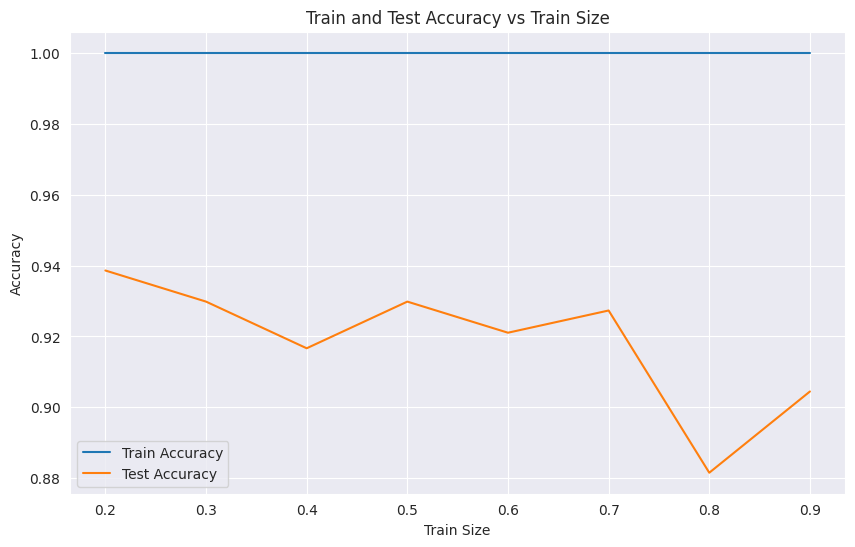

In [12]:
train_set = np.arange(0.2, 1.0, 0.1)
train_df = pd.DataFrame(columns=['train_size', 'train_accuracy', 'test_accuracy', 'classification_report', 'confusion_matrix'])

trained_models = joblib.Parallel(n_job=-1)(
    joblib.delayed(DT_classifier)(X=X, y=y, split_test_size=split) for split in train_set
)

for model in trained_models:
    report, conf_matrix, test_acc, train_acc = model.getReport()
    train_df = pd.concat([train_df, pd.DataFrame([{
        'train_size': model.split_test_size,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'classification_report': report, 
        'confusion_matrix': conf_matrix
    }])], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='train_size', y='train_accuracy', label='Train Accuracy')
sns.lineplot(data=train_df, x='train_size', y='test_accuracy', label='Test Accuracy')
plt.title('Train and Test Accuracy vs Train Size')
plt.xlabel('Train Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()